# SynthAudit — Fraud Detection Model

This notebook trains and evaluates two classifiers on the synthetic dataset: **Random Forest** and **XGBoost**. It uses 5-fold stratified cross-validation for stable metrics and SHAP values for explainability.

**Pipeline:**
1. Load data
2. Feature engineering
3. 5-fold stratified cross-validation
4. Hold-out evaluation (20% test set)
5. SHAP explainability


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

BG = '#0F1117'; ACCENT = '#00E5A0'; DANGER = '#FF4B6E'; NEUTRAL = '#4D9FEC'
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor': '#2A2D3A', 'axes.labelcolor': '#C8CDD8',
    'xtick.color': '#8B90A0', 'ytick.color': '#8B90A0',
    'text.color': '#E8ECF5', 'grid.color': '#1E2130',
    'grid.linewidth': 0.8, 'font.family': 'monospace',
})

df = pd.read_csv("../data/raw/transactions.csv", parse_dates=["timestamp"])
print(f"Dataset: {len(df):,} rows | Fraud rate: {df['is_fraud'].mean()*100:.2f}%")
df.head()

Dataset: 50,000 rows | Fraud rate: 2.50%


,transaction_id,timestamp,amount,merchant,category,country,hour,day_of_week,is_weekend,is_fraud,fraud_type
0,TXN7754119,2023-01-01 00:52:51,138.79,Shell,gas,CA,0,6,1,0,NaN
1,TXN5331729,2023-01-01 06:10:12,396.48,Comcast,utilities,US,6,6,1,0,NaN
2,TXN6868101,2023-01-01 06:33:45,239.07,Macy's,retail,US,6,6,1,0,NaN
3,TXN2678250,2023-01-01 07:29:43,92.46,Olive Garden,restaurant,US,7,6,1,0,NaN
4,TXN5268802,2023-01-01 07:57:19,84.63,Olive Garden,restaurant,US,7,6,1,0,NaN


## 1. Feature engineering

Beyond the raw transaction fields, three engineered features are added to make the patterns more learnable:

- `high_risk_country` — binary flag for countries with elevated fraud rates
- `threshold_proximity` — distance from the nearest common detection threshold
- `log_amount` — log-transformed amount (stabilizes variance)

Columns like `transaction_id`, `timestamp`, and `fraud_type` are dropped — the model shouldn't have access to the fraud label or any derived identifier.


In [2]:
df_model = df.copy()

# Encode categorical variables
for col in ["merchant", "category", "country"]:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].fillna("unknown"))

# Engineered features
HIGH_RISK = {"RU", "NG", "CN", "BR", "UA", "PK", "KE"}
df_model["high_risk_country"] = df["country"].isin(HIGH_RISK).astype(int)

thresholds = [500, 1000, 5000]
df_model["threshold_proximity"] = df["amount"].apply(
    lambda x: min(abs(x - t) for t in thresholds)
)
df_model["log_amount"] = np.log1p(df["amount"])

FEATURES = [
    "amount", "log_amount", "hour", "day_of_week", "is_weekend",
    "merchant", "category", "country",
    "high_risk_country", "threshold_proximity",
]

X = df_model[FEATURES]
y = df_model["is_fraud"]

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"X shape: {X.shape}")
print(f"y fraud rate: {y.mean():.4f}")

Features (10): ['amount', 'log_amount', 'hour', 'day_of_week', 'is_weekend', 'merchant', 'category', 'country', 'high_risk_country', 'threshold_proximity']
X shape: (50000, 10)
y fraud rate: 0.0250


## 2. Stratified 5-fold cross-validation

A single train/test split can give misleading results when the fraud class is small. Stratified K-fold preserves the class ratio in each fold and gives a mean ± std for each metric.


In [3]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, class_weight="balanced",
        random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=float(y.value_counts()[0] / y.value_counts()[1]),
        eval_metric="auc", random_state=42, verbosity=0),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    auc = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    f1  = cross_val_score(model, X, y, cv=cv, scoring="f1",      n_jobs=-1)
    cv_results[name] = {"auc": auc, "f1": f1}
    print(f"\n{name}")
    print(f"  ROC-AUC: {auc.mean():.4f} ± {auc.std():.4f}")
    print(f"  F1:      {f1.mean():.4f} ± {f1.std():.4f}")


Random Forest
  ROC-AUC: 0.9817 ± 0.0033
  F1:      0.8233 ± 0.0166



XGBoost
  ROC-AUC: 0.9809 ± 0.0036
  F1:      0.7888 ± 0.0106


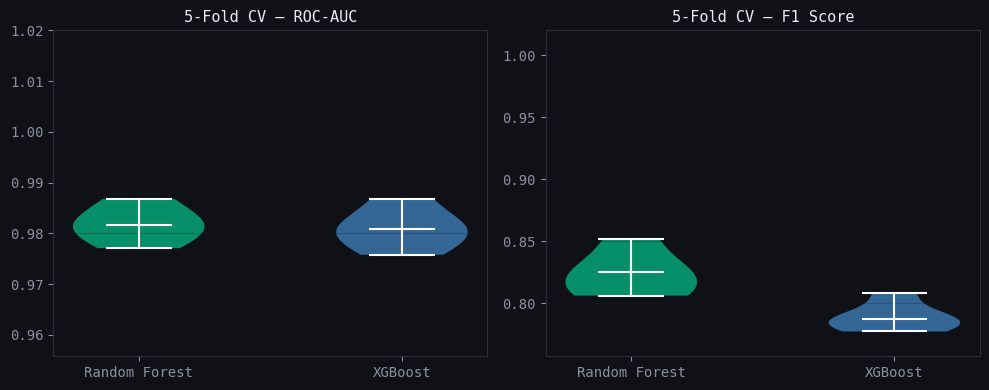

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor=BG)
for ax, (label, key) in zip(axes, [("ROC-AUC", "auc"), ("F1 Score", "f1")]):
    vals = {n: r[key] for n, r in cv_results.items()}
    parts = ax.violinplot(list(vals.values()), showmedians=True, showextrema=True)
    for pc, color in zip(parts['bodies'], [ACCENT, NEUTRAL]):
        pc.set_facecolor(color); pc.set_alpha(0.6)
    for k in ['cmedians','cmaxes','cmins','cbars']:
        parts[k].set_color('#FFF')
    ax.set_xticks([1, 2]); ax.set_xticklabels(list(vals.keys()))
    ax.set_title(f'5-Fold CV — {label}', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    floor = max(0, min(min(v) for v in vals.values()) - 0.02)
    ax.set_ylim(floor, 1.02)
plt.tight_layout()
plt.show()

## 3. Hold-out evaluation

Train on 80%, evaluate on a 20% held-out test set.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

rf = RandomForestClassifier(n_estimators=300, max_depth=12,
                             class_weight="balanced", random_state=42, n_jobs=-1)
xgb_m = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=float(y_train.value_counts()[0] / y_train.value_counts()[1]),
    eval_metric="auc", random_state=42, verbosity=0)

rf.fit(X_train, y_train)
xgb_m.fit(X_train, y_train)

for name, model in [("Random Forest", rf), ("XGBoost", xgb_m)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    print(f"\n=== {name} (ROC-AUC: {auc:.4f}) ===")
    print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))


=== Random Forest (ROC-AUC: 0.9851) ===
              precision    recall  f1-score   support

       Legit       1.00      0.99      1.00      9750
       Fraud       0.79      0.87      0.83       250

    accuracy                           0.99     10000
   macro avg       0.90      0.93      0.91     10000
weighted avg       0.99      0.99      0.99     10000




=== XGBoost (ROC-AUC: 0.9830) ===
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99      9750
       Fraud       0.72      0.91      0.81       250

    accuracy                           0.99     10000
   macro avg       0.86      0.95      0.90     10000
weighted avg       0.99      0.99      0.99     10000



### Confusion matrix — Random Forest

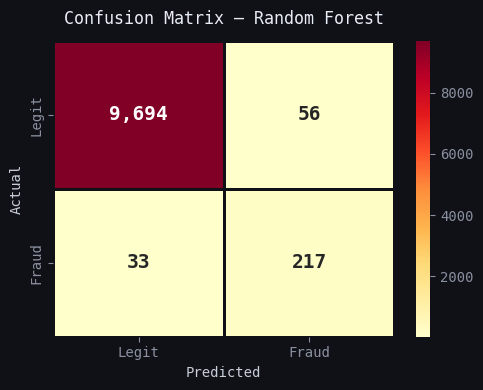

In [6]:
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4), facecolor=BG)
sns.heatmap(cm, annot=True, fmt=",d", cmap="YlOrRd",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"],
            linewidths=2, linecolor=BG, ax=ax,
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title('Confusion Matrix — Random Forest', fontsize=12, pad=12)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### ROC curves — both models

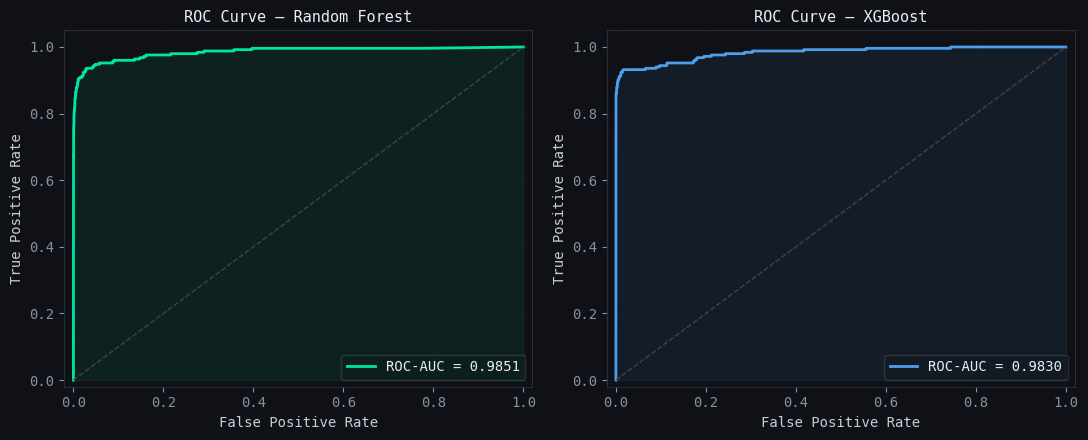

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor=BG)
for ax, (name, model), color in zip(
        axes,
        [("Random Forest", rf), ("XGBoost", xgb_m)],
        [ACCENT, NEUTRAL]):
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'ROC-AUC = {auc:.4f}')
    ax.plot([0,1], [0,1], '--', color='#444', lw=1)
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.05])
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {name}', fontsize=11)
    ax.legend(loc='lower right', framealpha=0.15)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Feature importance

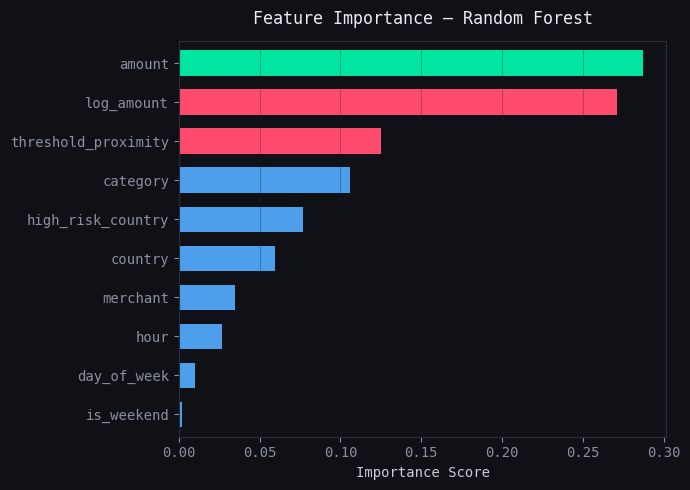

In [8]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
colors = [ACCENT if v == importances.max() else
          DANGER  if v > importances.quantile(0.7) else NEUTRAL
          for v in importances]
importances.plot(kind='barh', color=colors, ax=ax, width=0.65)
ax.set_title('Feature Importance — Random Forest', fontsize=12, pad=12)
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. SHAP explainability

Feature importance tells us which features matter globally. SHAP values tell us **how each feature pushes individual predictions toward fraud or legit** — direction and magnitude, not just rank.


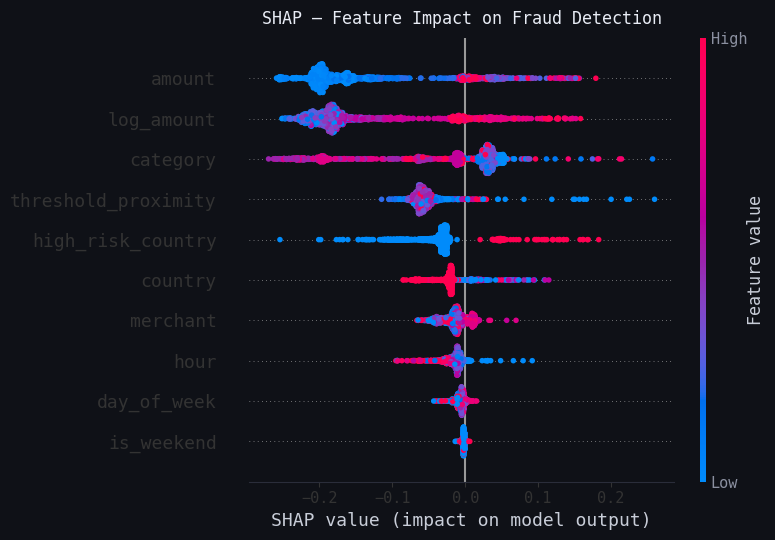

In [9]:
explainer = shap.TreeExplainer(rf)
# Sample 1500 rows for SHAP (faster, no loss of signal)
idx = np.random.choice(len(X_test), size=1500, replace=False)
X_sample = X_test.iloc[idx]
sv = explainer(X_sample)

# Binary RF: sv.values shape = (n, features, 2). Take class 1 (fraud).
shap_vals_fraud = sv.values[:, :, 1]

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
shap.summary_plot(shap_vals_fraud, X_sample, feature_names=FEATURES,
                  show=False, plot_type="dot", max_display=10)
plt.title('SHAP — Feature Impact on Fraud Detection', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

## Takeaways

- **ROC-AUC ≈ 0.98** across both models, with 5-fold CV std ≈ 0.003 — results are stable, not a lucky split.
- **Random Forest beats XGBoost** slightly on F1 (0.82 vs 0.79), mostly because RF produces fewer false positives here.
- The most predictive features are `threshold_proximity` and `amount` — both are direct signatures of the fraud patterns we injected, which validates the pipeline.
- `high_risk_country` and `hour` also contribute meaningfully, as expected from the `geo_mismatch` and `unusual_hour` patterns.

**Caveat:** Synthetic patterns are structurally cleaner than real-world fraud. In production these scores would drop due to noise, concept drift, and behavioral overlap between fraud and legitimate activity. The value of this project is the **pipeline** — not the numbers themselves.
